# 01 - Preprocesiranje podataka
Učitavanje biblioteka potrebnih za analizu i preprocesiranje podataka.

**Autor: Valentina**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

## Učitavanje podataka
Učitavamo dataset sa kreditnim karticama i prikazujemo osnovne informacije o strukturi.

In [2]:
df = pd.read_csv('../data/creditcard.csv')
print(df.shape)
print(df.head())


(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

## Analiza strukture
Prikazujemo kolone, tipove podataka i proveravamo da li ima nedostajućih vrednosti.

In [3]:
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum().sum())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
0


## Analiza raspodele klasa
Proveravamo koliko ima legitimnih transakcija a koliko prevara — ključno za razumevanje problema neravnoteže klasa.

In [4]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


## Vizualizacija podataka
Prikazujemo distribuciju iznosa transakcija po klasama, vreme transakcija i koje karakteristike najviše utiču na detekciju prevare.

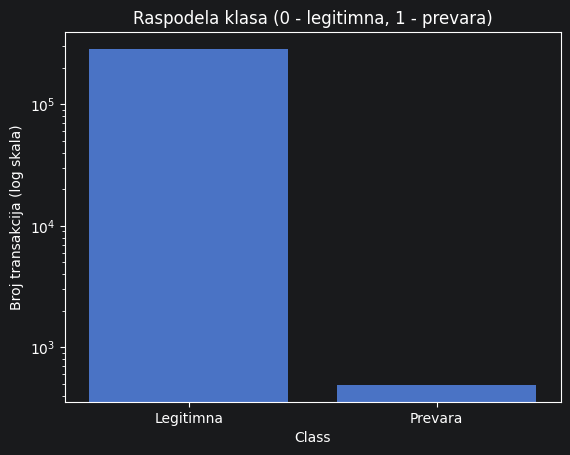

In [5]:
sb.countplot(x = 'Class', data = df)
plt.title('Raspodela klasa (0 - legitimna, 1 - prevara)')
plt.xticks([0,1], ['Legitimna', 'Prevara'])
plt.yscale('log')
plt.ylabel('Broj transakcija (log skala)')
plt.show()

## Grafička analiza
Prikazujemo distribuciju iznosa i vremena transakcija po klasama, kao i koje kolone najviše utiču na detekciju prevare.

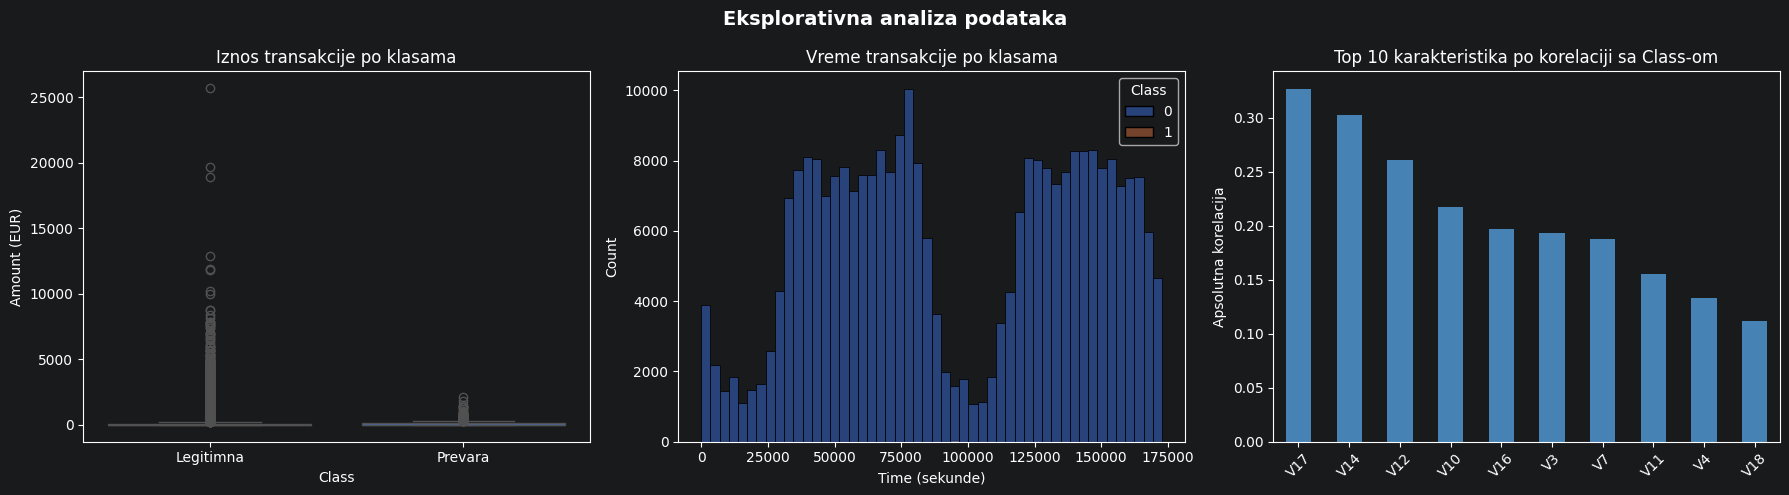

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sb.boxplot(x='Class', y='Amount', data=df, ax=axes[0])
axes[0].set_title('Iznos transakcije po klasama')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Legitimna', 'Prevara'])
axes[0].set_ylabel('Amount (EUR)')

sb.histplot(data=df, x='Time', hue='Class', ax=axes[1], bins=50, legend=True)
axes[1].set_title('Vreme transakcije po klasama')
axes[1].set_xlabel('Time (sekunde)')

korrelacije = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False).head(10)
korrelacije.plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Top 10 karakteristika po korelaciji sa Class-om')
axes[2].set_ylabel('Apsolutna korelacija')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Eksplorativna analiza podataka', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Skaliranje podataka
Primenjujemo StandardScaler na kolone Amount i Time koje nisu na istoj skali kao PCA komponente V1-V28.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

print(df[['Time', 'Amount']].describe())

               Time        Amount
count  2.848070e+05  2.848070e+05
mean  -5.109395e-17 -3.672378e-17
std    1.000002e+00  1.000002e+00
min   -1.996583e+00 -3.532294e-01
25%   -8.552120e-01 -3.308401e-01
50%   -2.131453e-01 -2.652715e-01
75%    9.372174e-01 -4.471707e-02
max    1.642058e+00  1.023622e+02


## Podela podataka
Delimo dataset na trening (80%) i test (20%) set uz stratifikaciju da bi procenat prevara bio isti u oba seta.

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"Prevare u treningu: {y_train.sum()}")
print(f"Prevare u testu: {y_test.sum()}")

X_train: (227845, 30)
X_test: (56962, 30)
Prevare u treningu: 394
Prevare u testu: 98


## Balansiranje klasa — SMOTE
Zbog ekstremne neravnoteže klasa (577:1) primenjujemo SMOTE koji generiše sintetičke primere prevara isključivo na trening setu.

In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Pre SMOTE: {y_train.value_counts().to_dict()}")
print(f"Posle SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")


Pre SMOTE: {0: 227451, 1: 394}
Posle SMOTE: {0: 227451, 1: 227451}


## Čuvanje preprocesiranih podataka
Čuvamo preprocesirane podatke u CSV fajlove koje će koristiti ostali notebookovi.

In [10]:
import os
os.makedirs('../data', exist_ok=True)

X_train_sm.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
pd.Series(y_train_sm).to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

print("Podaci su sacuvani!")

Podaci su sacuvani!
